# RQ2 — Peak Performance Analysis by Position

**Research question:** Do players in different positions exhibit different peak-performance profiles?

**Approach:** define performance = goals + assists, join season stats onto the backbone, identify each player's single best season, then compare peak score and age at peak across positions.

In [1]:
import cProfile
import io
import pstats
import sys
import time
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

# Resolve project root whether running locally or on Colab
_candidates = [
    Path("/Users/fqxin/Desktop/1019_Py/football_lifecycle"),
    Path("/content/drive/MyDrive/football_lifecycle"),
    Path("../"),  # if notebook is inside notebooks/
]
PROJECT_ROOT = next(
    (p.resolve() for p in _candidates if (p / "data" / "processed").exists()), None
)
if PROJECT_ROOT is None:
    raise RuntimeError("Cannot find project root. Add your path to _candidates above.")

sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

INTERIM       = PROJECT_ROOT / "data" / "interim"
PROCESSED     = PROJECT_ROOT / "data" / "processed"
OUT_TABLES    = PROJECT_ROOT / "outputs" / "tables"
OUT_FIGURES   = PROJECT_ROOT / "outputs" / "figures"
OUT_PROFILING = PROJECT_ROOT / "outputs" / "profiling"

for d in [OUT_TABLES, OUT_FIGURES, OUT_PROFILING]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 150, "font.size": 11})

POSITION_ORDER = ["Goalkeeper", "Defender", "Midfielder", "Forward"]
POSITION_PALETTE = {
    "Goalkeeper": "#1976D2",
    "Defender":   "#388E3C",
    "Midfielder": "#F57C00",
    "Forward":    "#D32F2F",
}


Project root: /Users/fqxin/Desktop/1019_Py/football_lifecycle


In [ ]:
# import pandas as pd

# backbone = pd.read_parquet("/Users/zhangjinao/Desktop/player_lifecycle_backbone.parquet")
# perf = pd.read_parquet("/Users/zhangjinao/Desktop/player_performances_clean.parquet")

# print(backbone.columns)
# print(perf.columns)

Index(['player_id', 'market_value_date', 'market_value_eur', 'player_name',
       'date_of_birth', 'raw_position', 'raw_sub_position', 'broad_position',
       'age_days', 'age_years', 'n_market_value_obs', 'market_value_rank_desc',
       'is_peak_value_obs'],
      dtype='object')
Index(['player_id', 'season', 'season_start_year', 'competition_id',
       'competition_name', 'team_id', 'team_name', 'nb_in_group',
       'nb_on_pitch', 'goals', 'own_goals', 'assists', 'subed_in', 'subed_out',
       'yellow_cards', 'second_yellow_cards', 'direct_red_cards',
       'penalty_goals', 'minutes_played', 'goals_conceded', 'clean_sheets'],
      dtype='object')


## 1) Load data

In [2]:
backbone = pd.read_parquet(PROCESSED / "player_lifecycle_backbone.parquet")
perf = pd.read_parquet(INTERIM / "player_performances_clean.parquet")

print("Backbone shape:", backbone.shape)
print("Performance shape:", perf.shape)
print("\nBackbone columns:", backbone.columns.tolist())
print("Performance columns:", perf.columns.tolist())

Backbone shape: (836635, 13)
Performance shape: (1878719, 21)

Backbone columns: ['player_id', 'market_value_date', 'market_value_eur', 'player_name', 'date_of_birth', 'raw_position', 'raw_sub_position', 'broad_position', 'age_days', 'age_years', 'n_market_value_obs', 'market_value_rank_desc', 'is_peak_value_obs']
Performance columns: ['player_id', 'season', 'season_start_year', 'competition_id', 'competition_name', 'team_id', 'team_name', 'nb_in_group', 'nb_on_pitch', 'goals', 'own_goals', 'assists', 'subed_in', 'subed_out', 'yellow_cards', 'second_yellow_cards', 'direct_red_cards', 'penalty_goals', 'minutes_played', 'goals_conceded', 'clean_sheets']


## 2) Build the performance score

* Create `performance = goals + assists`
* Fills NaNs with 0

In [3]:
perf['performance'] = perf['goals'].fillna(0) + perf['assists'].fillna(0)

## 3) Merge tables by year 

* Inner-join on `(player_id, market_value_year = season_start_year)`

In [4]:
# Parse dates and extract year
backbone['market_value_date'] = pd.to_datetime(backbone['market_value_date'])
backbone['market_value_year'] = backbone['market_value_date'].dt.year

In [5]:
print(backbone[['player_id', 'market_value_date', 'market_value_year']].head())
print(perf[['player_id', 'season', 'season_start_year', 'goals', 'assists']].head())

  player_id market_value_date  market_value_year
0        10        2004-10-03               2004
1        10        2005-01-06               2005
2        10        2005-05-04               2005
3        10        2005-09-29               2005
4        10        2006-01-08               2006
  player_id season  season_start_year  goals  assists
0         1  08/09               2008      0        0
1         1  07/08               2007      1        0
2         1  06/07               2006      0        0
3         1  06/07               2006      0        0
4         1  05/06               2005      1        1


In [6]:
df = backbone.merge(
    perf,
    left_on=['player_id', 'market_value_year'],
    right_on=['player_id', 'season_start_year'],
    how='inner'
)

In [7]:
print(df.shape)
print(df.columns.tolist())
df[['player_id', 'player_name', 'market_value_date', 'market_value_year',
    'season', 'season_start_year', 'broad_position', 'age_years',
    'goals', 'assists', 'performance']].head()

(2230254, 35)
['player_id', 'market_value_date', 'market_value_eur', 'player_name', 'date_of_birth', 'raw_position', 'raw_sub_position', 'broad_position', 'age_days', 'age_years', 'n_market_value_obs', 'market_value_rank_desc', 'is_peak_value_obs', 'market_value_year', 'season', 'season_start_year', 'competition_id', 'competition_name', 'team_id', 'team_name', 'nb_in_group', 'nb_on_pitch', 'goals', 'own_goals', 'assists', 'subed_in', 'subed_out', 'yellow_cards', 'second_yellow_cards', 'direct_red_cards', 'penalty_goals', 'minutes_played', 'goals_conceded', 'clean_sheets', 'performance']


,player_id,player_name,market_value_date,market_value_year,season,season_start_year,broad_position,age_years,goals,assists,performance
0,10,Miroslav Klose (10),2004-10-03,2004,04/05,2004,Forward,26.318960,15,10,25
1,10,Miroslav Klose (10),2004-10-03,2004,04/05,2004,Forward,26.318960,2,0,2
2,10,Miroslav Klose (10),2004-10-03,2004,04/05,2004,Forward,26.318960,0,1,1
3,10,Miroslav Klose (10),2004-10-03,2004,04/05,2004,Forward,26.318960,0,0,0
4,10,Miroslav Klose (10),2005-01-06,2005,05/06,2005,Forward,26.579055,25,13,38


## 4) Extract peak-performance per player

Sort by `performance` descending within each player, then take the first row. `df_peak` has one row per player — their best goals+assists season and their age at that moment.

In [9]:
df_peak = (
    df.sort_values(['player_id', 'performance'], ascending=[True, False])
      .groupby('player_id', as_index=False)
      .first()
)

In [10]:
print(df_peak.shape)
df_peak[['player_id', 'player_name', 'broad_position', 'age_years', 'performance']].head()

(58782, 35)


,player_id,player_name,broad_position,age_years,performance
0,10,Miroslav Klose (10),Forward,26.579055,38
1,100001,Carlos Auzqui (100001),Forward,29.062286,8
2,100011,Éverton Silva (100011),Defender,26.817248,2
3,100012,Liridon Osmanaj (100012),Forward,23.186858,7
4,1000135,Joselu Pérez (1000135),Forward,20.281999,4


## 5) Summarize peak performance by position

In [11]:
summary = (
    df_peak.groupby('broad_position')
    .agg(
        n_players=('player_id', 'nunique'),
        mean_perf=('performance', 'mean'),
        median_perf=('performance', 'median'),
        mean_age=('age_years', 'mean'),
        median_age=('age_years', 'median')
    )
    .reset_index()
)

summary

/var/folders/_j/__475r_x6hs0kv9nsh3rt4c40000gn/T/ipykernel_27911/1270534577.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_peak.groupby('broad_position')


,broad_position,n_players,mean_perf,median_perf,mean_age,median_age
0,Defender,19205,3.664098,3.0,23.895426,23.301848
1,Forward,15917,11.861029,11.0,23.901204,23.290897
2,Goalkeeper,6219,0.201158,0.0,22.321580,20.739220
3,Midfielder,17441,6.925922,5.0,23.789327,23.112936
4,Other,0,<NA>,<NA>,NaN,NaN


In [12]:
summary.round(3).to_csv(OUT_TABLES / "C_rq2_summary_table.csv", index=False)

## 6) Visualization

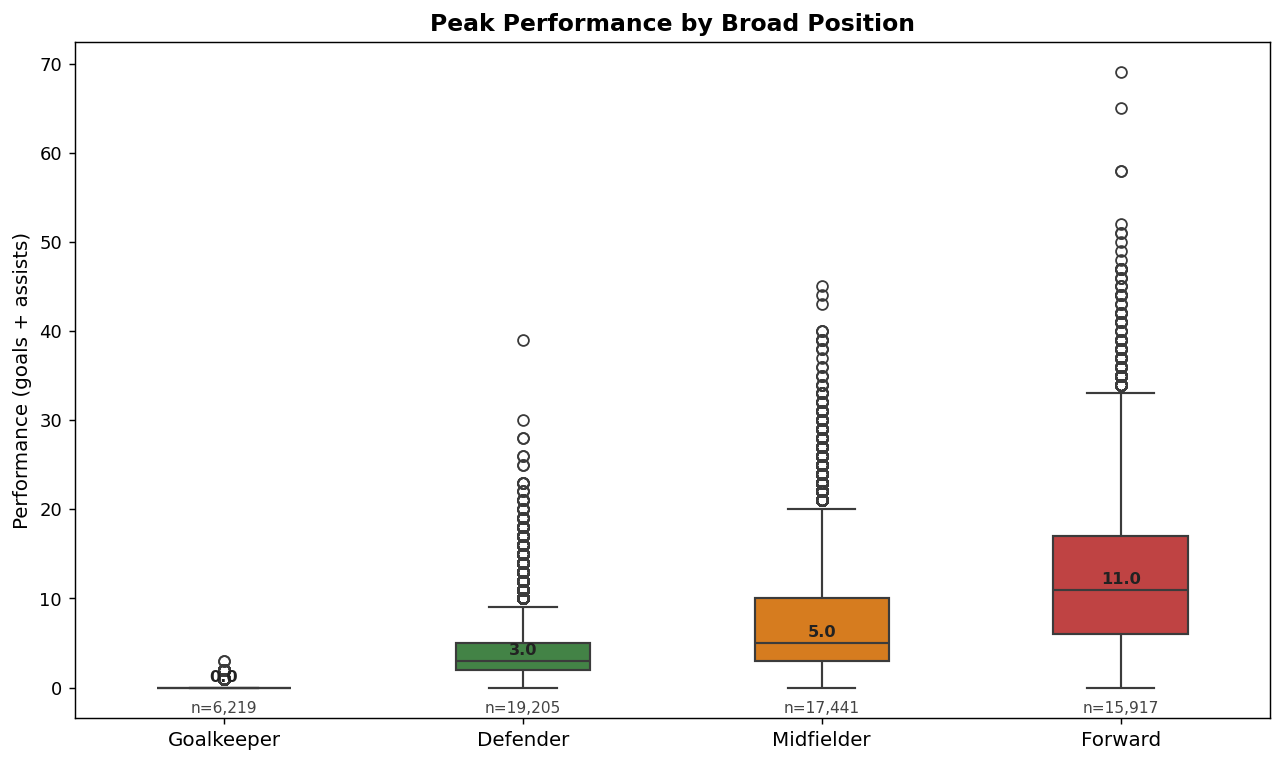

In [13]:
data = df_peak[df_peak["broad_position"].isin(POSITION_ORDER)].copy()
data["broad_position"] = pd.Categorical(
    data["broad_position"], categories=POSITION_ORDER, ordered=True
)

_, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=data,
    x="broad_position",
    y="performance",
    hue="broad_position",
    order=POSITION_ORDER,
    hue_order=POSITION_ORDER,
    palette=POSITION_PALETTE,
    width=0.45,
    showfliers=True,
    linewidth=1.2,
    legend=False,
    ax=ax,
)

for i, pos in enumerate(POSITION_ORDER):
    s = data.loc[data["broad_position"] == pos, "performance"].dropna()
    median_val = s.median()
    ax.text(i, median_val + 0.3, f"{median_val:.1f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="#222222")

counts = data.groupby("broad_position", observed=True)["performance"].count()
for i, pos in enumerate(POSITION_ORDER):
    n = counts.get(pos, 0)
    ax.text(i, ax.get_ylim()[0] + 0.3, f"n={n:,}",
            ha="center", va="bottom", fontsize=8.5, color="#444444")

ax.set_xlabel("")
ax.set_ylabel("Performance (goals + assists)", fontsize=11)
ax.set_title("Peak Performance by Broad Position", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.savefig(OUT_FIGURES / "C_rq2_peak_performance.png", dpi=200, bbox_inches="tight")
plt.show()


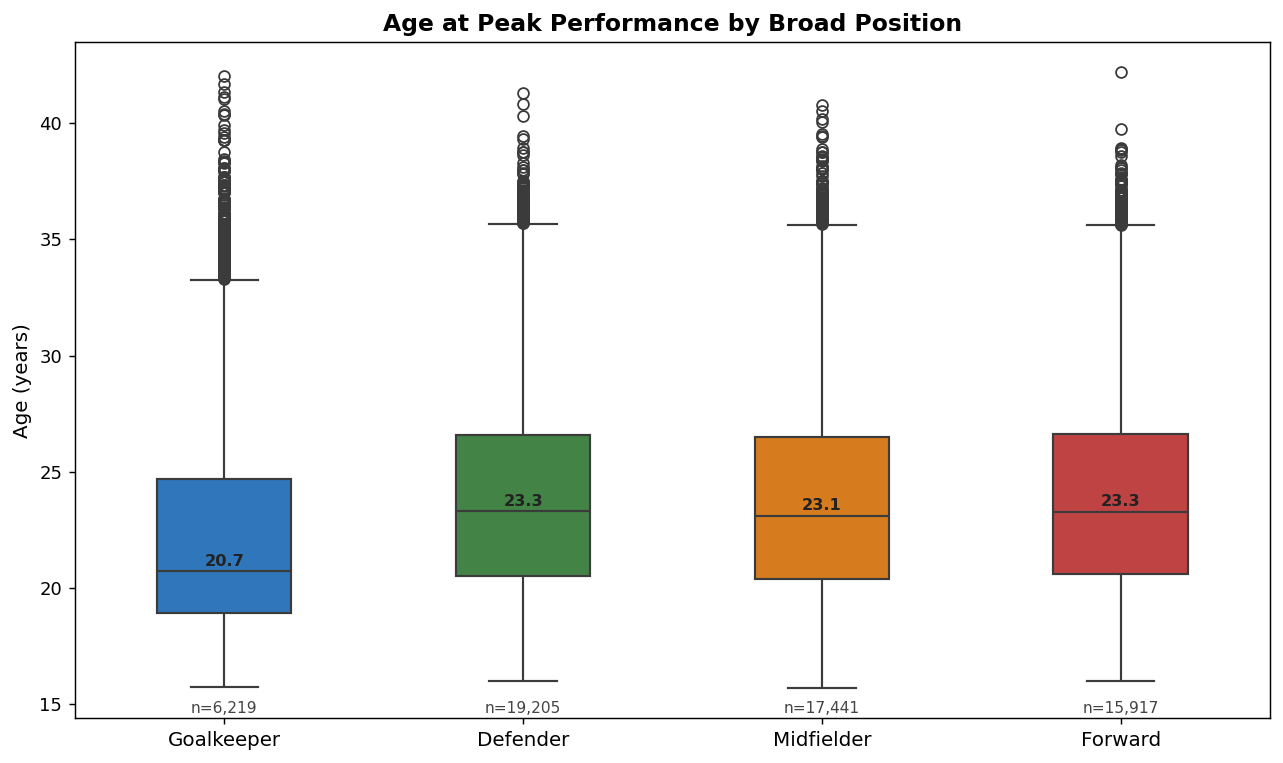

In [14]:
data_age = df_peak[df_peak["broad_position"].isin(POSITION_ORDER)].copy()
data_age["broad_position"] = pd.Categorical(
    data_age["broad_position"], categories=POSITION_ORDER, ordered=True
)

_, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=data_age,
    x="broad_position",
    y="age_years",
    hue="broad_position",
    order=POSITION_ORDER,
    hue_order=POSITION_ORDER,
    palette=POSITION_PALETTE,
    width=0.45,
    showfliers=True,
    linewidth=1.2,
    legend=False,
    ax=ax,
)

for i, pos in enumerate(POSITION_ORDER):
    s = data_age.loc[data_age["broad_position"] == pos, "age_years"].dropna()
    median_val = s.median()
    ax.text(i, median_val + 0.1, f"{median_val:.1f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold", color="#222222")

counts_age = data_age.groupby("broad_position", observed=True)["age_years"].count()
for i, pos in enumerate(POSITION_ORDER):
    n = counts_age.get(pos, 0)
    ax.text(i, ax.get_ylim()[0] + 0.1, f"n={n:,}",
            ha="center", va="bottom", fontsize=8.5, color="#444444")

ax.set_xlabel("")
ax.set_ylabel("Age (years)", fontsize=11)
ax.set_title("Age at Peak Performance by Broad Position", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=10)
plt.tight_layout()
plt.savefig(OUT_FIGURES / "C_rq2_peak_age.png", dpi=200, bbox_inches="tight")
plt.show()


## 7) Profiling and optimization

In [15]:
# --- cProfile: baseline peak extraction ---
# Profile the current approach: sort_values + groupby.first() on the 2.2M-row df
pr = cProfile.Profile()
pr.enable()

_pk_profiled = (
    df.sort_values(['player_id', 'performance'], ascending=[True, False])
      .groupby('player_id', as_index=False)
      .first()
)

pr.disable()

_profile_stream = io.StringIO()
pstats.Stats(pr, stream=_profile_stream).sort_stats('cumulative').print_stats(20)
_profile_text = _profile_stream.getvalue()
print(_profile_text)

         7906 function calls (7805 primitive calls) in 0.864 seconds

   Ordered by: cumulative time
   List reduced from 524 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.893    0.446 /Users/fqxin/Desktop/1019_Py/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
        2    0.000    0.000    0.893    0.446 {built-in method builtins.exec}
        1    0.000    0.000    0.576    0.576 /Users/fqxin/Desktop/1019_Py/.venv/lib/python3.10/site-packages/pandas/core/groupby/groupby.py:3344(first)
        1    0.000    0.000    0.576    0.576 /Users/fqxin/Desktop/1019_Py/.venv/lib/python3.10/site-packages/pandas/core/groupby/groupby.py:1898(_agg_general)
        1    0.000    0.000    0.576    0.576 /Users/fqxin/Desktop/1019_Py/.venv/lib/python3.10/site-packages/pandas/core/groupby/groupby.py:1964(_cython_agg_general)
        1    0.000    0.000    0.575    0.575 /Users/fq

In [16]:
# --- Benchmark: sort_values+groupby.first (baseline) vs groupby.idxmax (optimized) ---
# Optimization: idxmax does a single O(n) scan per group — no sort required.

t0 = time.perf_counter()
_baseline_result = (
    df.sort_values(['player_id', 'performance'], ascending=[True, False])
      .groupby('player_id', as_index=False)
      .first()
)
t_baseline = time.perf_counter() - t0

t0 = time.perf_counter()
_idx = df.groupby('player_id')['performance'].idxmax()
_opt_result = df.loc[_idx].reset_index(drop=True)
t_opt = time.perf_counter() - t0

print(f"Baseline  (sort_values + groupby.first): {t_baseline:.3f}s")
print(f"Optimized (groupby.idxmax):              {t_opt:.3f}s")
print(f"Speedup: {t_baseline / t_opt:.1f}x")

# Sanity check: same peak performance score per player
_b = _baseline_result.set_index('player_id')['performance'].sort_index()
_o = _opt_result.set_index('player_id')['performance'].sort_index()
print(f"\nPeak scores match: {_b.equals(_o)}")
print(f"Player count — baseline: {len(_baseline_result)}, optimized: {len(_opt_result)}")

Baseline  (sort_values + groupby.first): 0.859s
Optimized (groupby.idxmax):              0.090s
Speedup: 9.5x

Peak scores match: True
Player count — baseline: 58782, optimized: 58782


In [17]:
# --- Save C_rq2_profile.md ---
_profile_md = f"""# C RQ2 Profiling Note

## Pipeline
RQ2 peak performance extraction from merged backbone x performance table ({len(df):,} rows, {df['player_id'].nunique():,} players).

## Bottleneck identified
Extracting each player's best row from the {len(df):,}-row merged DataFrame.
**Baseline** (`sort_values` + `groupby.first()`): {t_baseline:.3f}s
**Optimized** (`groupby.idxmax()`): {t_opt:.3f}s
**Speedup: {t_baseline / t_opt:.1f}x**

## Optimization strategy
Replaced O(n log n) `sort_values(['player_id', 'performance'])` followed by
`groupby.first()` with a single O(n) `groupby('player_id')['performance'].idxmax()`.
idxmax scans each group once to return the index of the maximum performance value;
`.loc[idx]` then retrieves those rows without sorting the full {len(df):,}-row DataFrame.

## cProfile top functions (baseline peak extraction)
```
{_profile_text.strip()}
```
"""

_profile_out = OUT_PROFILING / "C_rq2_profile.md"
_profile_out.write_text(_profile_md)
print(f"Saved: {_profile_out}")

Saved: /Users/fqxin/Desktop/1019_Py/football_lifecycle/outputs/profiling/C_rq2_profile.md
